<a href="https://colab.research.google.com/github/Sherry66410/Weather-forecasting-App/blob/main/Copy_of_rs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
df=pd.read_csv("/content/kerala_weather1.csv",skiprows=17,delimiter=',')

In [ ]:
df

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,PS,WS2M,T2MDEW,ALLSKY_SFC_UV_INDEX
0,1981,1,25.71,28.30,23.45,82.70,17.75,100.05,3.13,22.50,-999.0
1,1981,2,25.42,27.87,23.31,79.81,13.24,100.08,3.02,21.61,-999.0
2,1981,3,25.30,28.19,22.71,80.64,6.25,100.08,2.88,21.65,-999.0
3,1981,4,25.34,28.65,22.36,77.97,0.39,100.14,2.77,21.06,-999.0
4,1981,5,25.09,28.10,22.00,72.93,1.44,100.22,2.35,19.66,-999.0
...,...,...,...,...,...,...,...,...,...,...,...
16490,2026,55,27.62,31.60,25.39,71.55,3.96,99.63,1.15,21.89,-999.0
16491,2026,56,27.21,30.24,25.21,72.73,6.63,99.83,1.22,21.89,-999.0
16492,2026,57,27.38,31.26,24.79,72.84,2.53,99.75,1.32,21.95,-999.0
16493,2026,58,27.50,31.22,25.14,71.06,2.47,99.57,1.18,21.62,-999.0


In [ ]:
df.dtypes

,0
YEAR,int64
DOY,int64
T2M,float64
T2M_MAX,float64
T2M_MIN,float64
RH2M,float64
PRECTOTCORR,float64
PS,float64
WS2M,float64
T2MDEW,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16495 entries, 0 to 16494
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YEAR                 16495 non-null  int64  
 1   DOY                  16495 non-null  int64  
 2   T2M                  16495 non-null  float64
 3   T2M_MAX              16495 non-null  float64
 4   T2M_MIN              16495 non-null  float64
 5   RH2M                 16495 non-null  float64
 6   PRECTOTCORR          16495 non-null  float64
 7   PS                   16495 non-null  float64
 8   WS2M                 16495 non-null  float64
 9   T2MDEW               16495 non-null  float64
 10  ALLSKY_SFC_UV_INDEX  16495 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 1.4 MB


In [ ]:
df["DATE"] = pd.to_datetime(
    df["YEAR"].astype(str) + "-" + df["DOY"].astype(str),
    format="%Y-%j"
)
df.set_index("DATE", inplace=True)
df.drop(columns=["YEAR", "DOY"], inplace=True)
df.sort_index(inplace=True)

In [ ]:
df = df.replace(-999.0, np.nan)

df.head()

,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,PS,WS2M,T2MDEW,ALLSKY_SFC_UV_INDEX
DATE,,,,,,,,,
1981-01-01,25.71,28.30,23.45,82.70,17.75,100.05,3.13,22.50,NaN
1981-01-02,25.42,27.87,23.31,79.81,13.24,100.08,3.02,21.61,NaN
1981-01-03,25.30,28.19,22.71,80.64,6.25,100.08,2.88,21.65,NaN
1981-01-04,25.34,28.65,22.36,77.97,0.39,100.14,2.77,21.06,NaN
1981-01-05,25.09,28.10,22.00,72.93,1.44,100.22,2.35,19.66,NaN


In [ ]:
df.isna().sum()

,0
T2M,0
T2M_MAX,0
T2M_MIN,0
RH2M,0
PRECTOTCORR,0
PS,0
WS2M,0
T2MDEW,0
ALLSKY_SFC_UV_INDEX,7365


In [ ]:
df.shape

(16495, 9)

In [ ]:
df.drop(columns=["ALLSKY_SFC_UV_INDEX"], inplace=True)


# Clip to clean date range
df = df.loc["1981-01-01":"2026-02-28"].copy()



In [ ]:
df

,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,PS,WS2M,T2MDEW
DATE,,,,,,,,
1981-01-01,25.71,28.30,23.45,82.70,17.75,100.05,3.13,22.50
1981-01-02,25.42,27.87,23.31,79.81,13.24,100.08,3.02,21.61
1981-01-03,25.30,28.19,22.71,80.64,6.25,100.08,2.88,21.65
1981-01-04,25.34,28.65,22.36,77.97,0.39,100.14,2.77,21.06
1981-01-05,25.09,28.10,22.00,72.93,1.44,100.22,2.35,19.66
...,...,...,...,...,...,...,...,...
2026-02-24,27.62,31.60,25.39,71.55,3.96,99.63,1.15,21.89
2026-02-25,27.21,30.24,25.21,72.73,6.63,99.83,1.22,21.89
2026-02-26,27.38,31.26,24.79,72.84,2.53,99.75,1.32,21.95


In [ ]:
#Exploratory Data Analysis

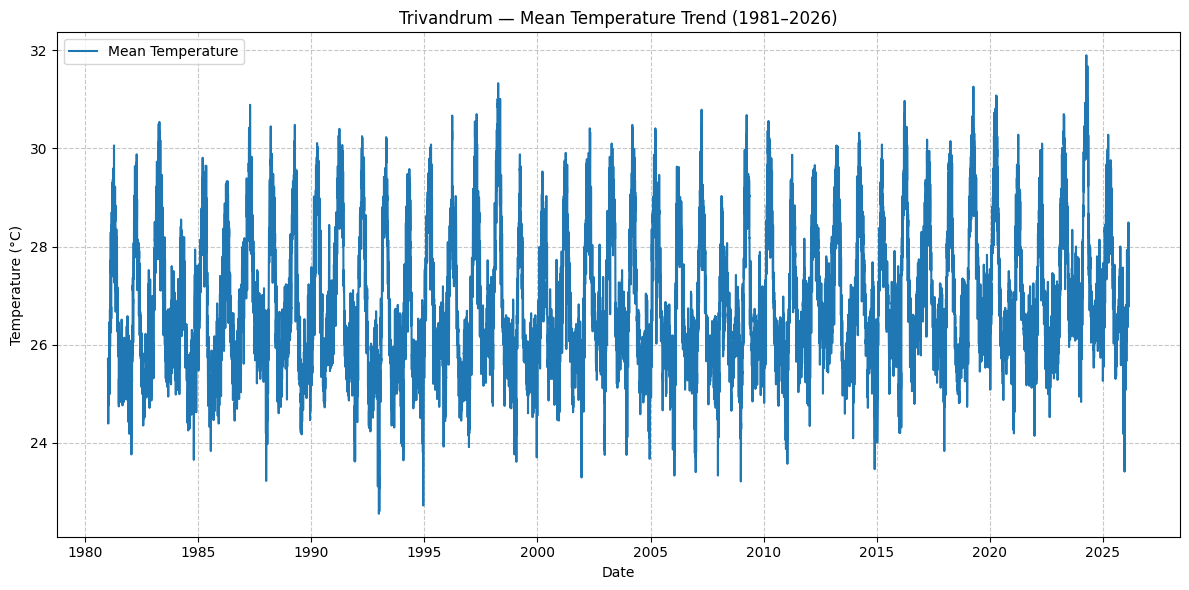

In [ ]:
#Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df["T2M"], label="Mean Temperature")
plt.title("Trivandrum — Mean Temperature Trend (1981–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

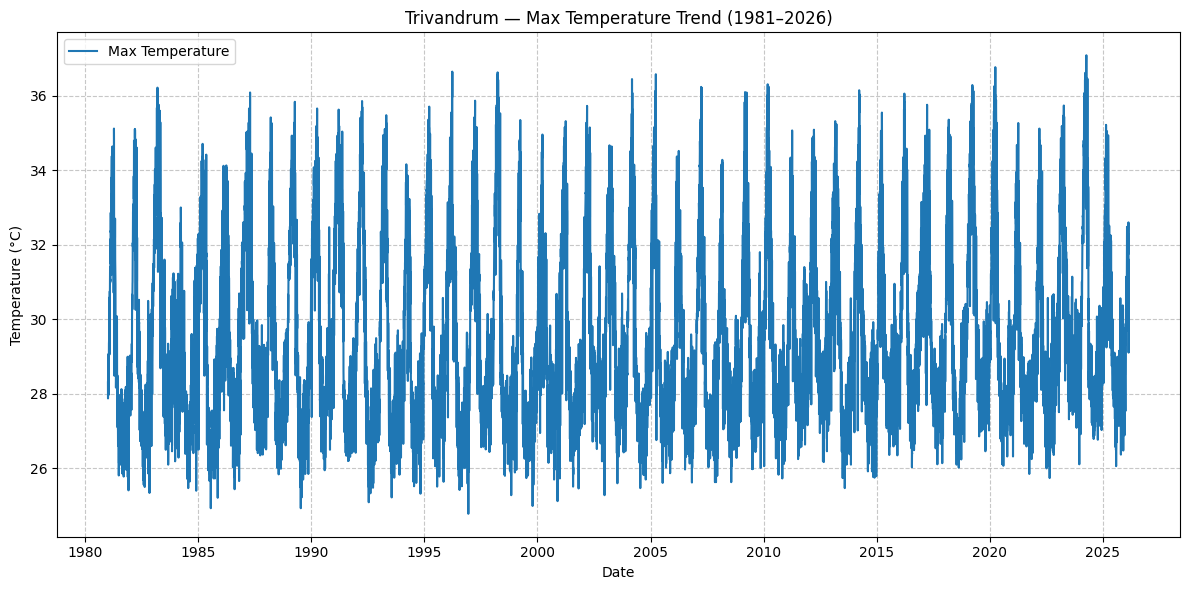

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df["T2M_MAX"], label="Max Temperature")
plt.title("Trivandrum — Max Temperature Trend (1981–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

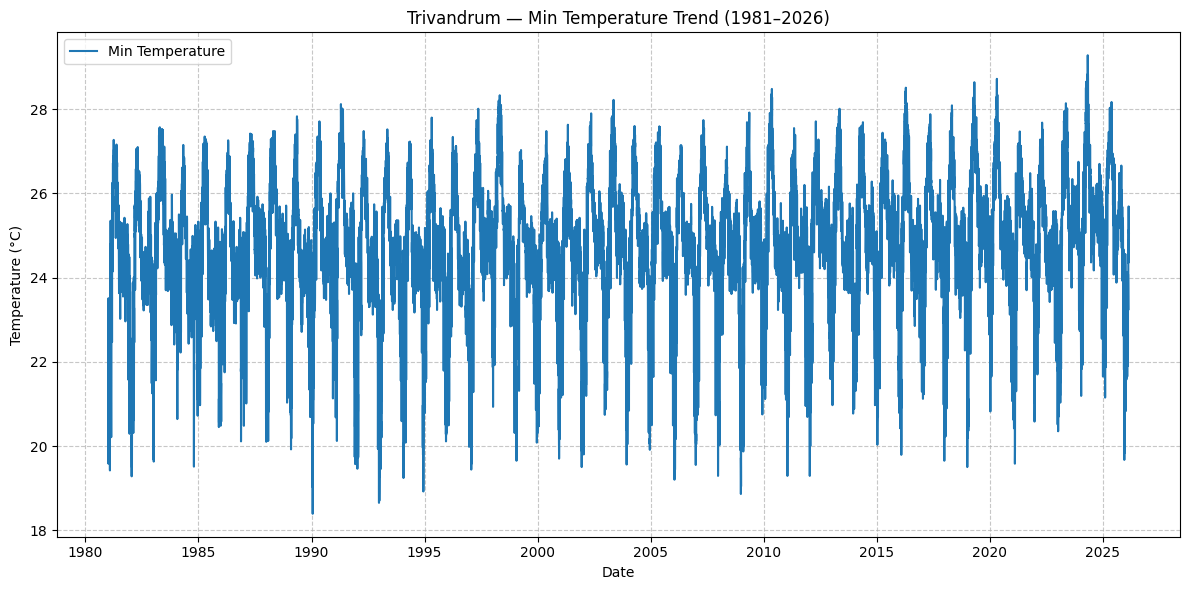

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df["T2M_MIN"], label="Min Temperature")
plt.title("Trivandrum — Min Temperature Trend (1981–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

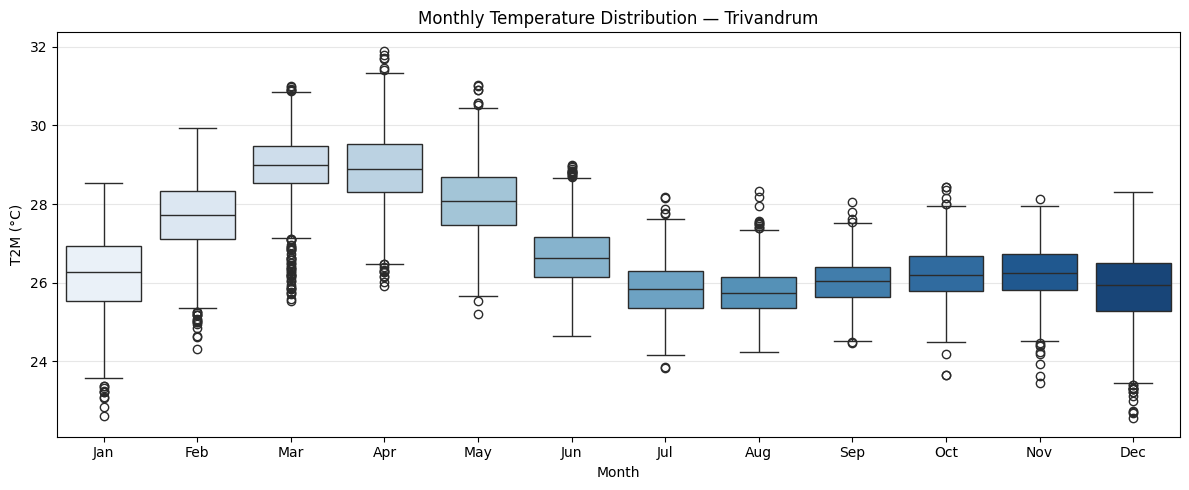

In [ ]:
#Seasonal box plot(monthly)
fig, ax = plt.subplots(figsize=(12, 5))
df_plot = df.copy()
df_plot["Month"] = df_plot.index.month
sns.boxplot(data=df_plot, x="Month", y="T2M",
            palette="Blues", ax=ax)
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Monthly Temperature Distribution — Trivandrum")
ax.set_ylabel("T2M (°C)"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

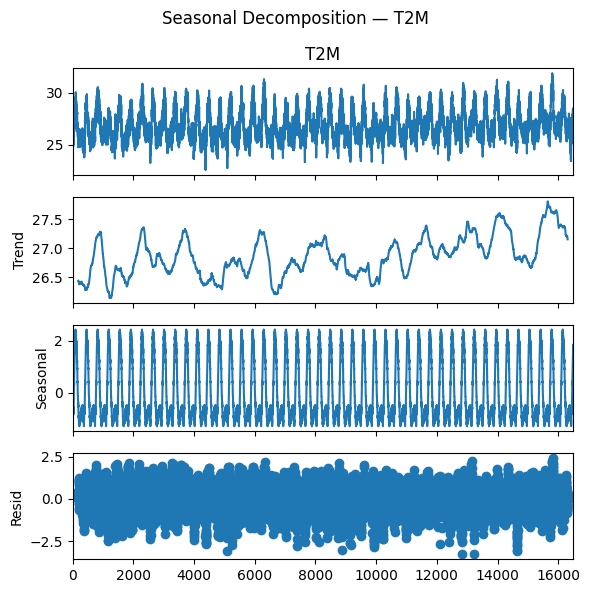

In [ ]:
#Seasonal Decomposition
decomp = seasonal_decompose(df["T2M"], model="additive", period=365)
fig = decomp.plot()
fig.set_size_inches(6, 6)
plt.suptitle("Seasonal Decomposition — T2M", fontsize=12)
plt.tight_layout(); plt.show()

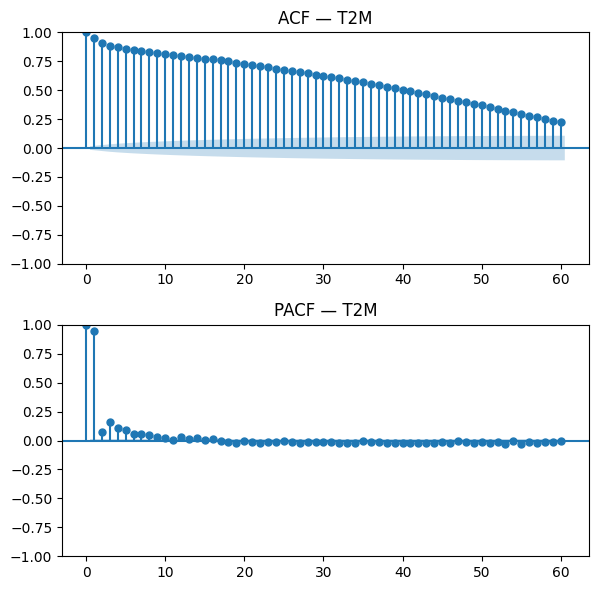

In [ ]:
#ACF and PACF
fig, axes = plt.subplots(2,1, figsize=(6, 6
                                        ))
plot_acf(df["T2M"],  lags=60, ax=axes[0], title="ACF — T2M")
plot_pacf(df["T2M"], lags=60, ax=axes[1], title="PACF — T2M")
plt.tight_layout(); plt.show()

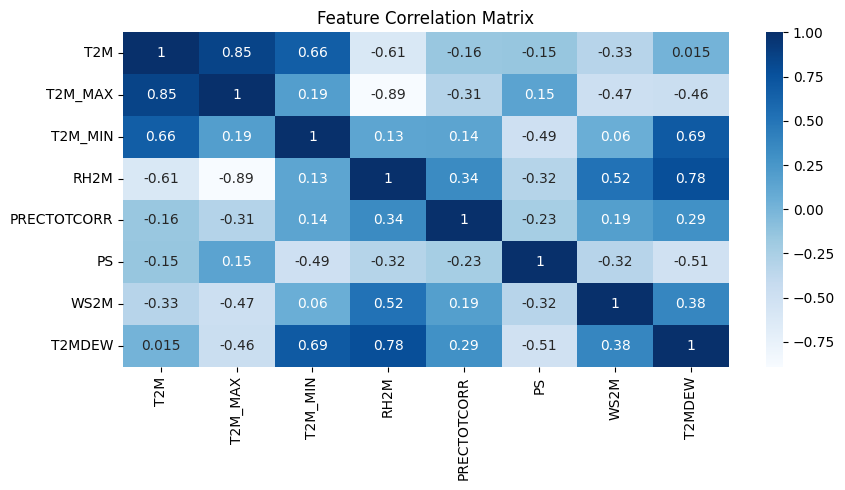

In [ ]:
#Correlation heat map
fig, ax = plt.subplots(figsize=(9, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="Blues")
ax.set_title("Feature Correlation Matrix")
plt.tight_layout(); plt.show()

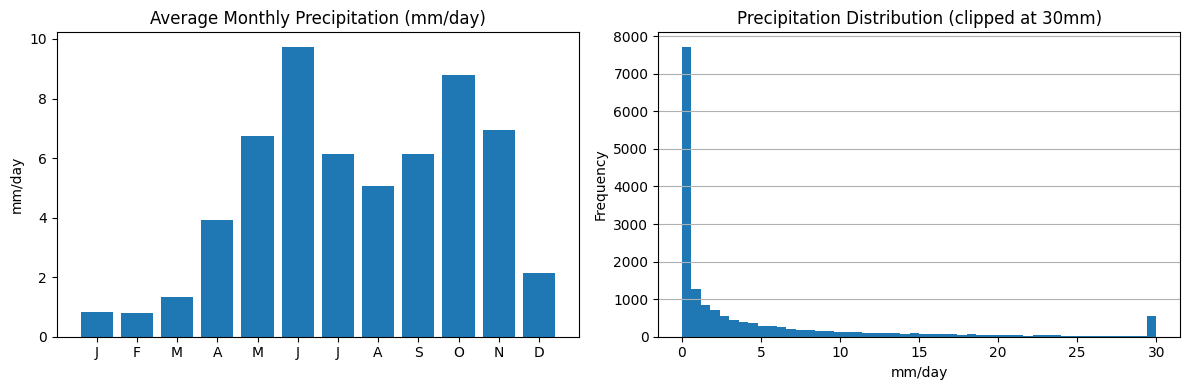

In [ ]:
#Precipitation distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_plot["MONTH"] = df_plot.index.month
monthly_rain = df.groupby(df.index.month)["PRECTOTCORR"].mean()
axes[0].bar(range(1, 13), monthly_rain.values)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
axes[0].set_title("Average Monthly Precipitation (mm/day)")
axes[0].set_ylabel("mm/day")

axes[1].hist(df["PRECTOTCORR"].clip(0, 30), bins=50)
axes[1].set_title("Precipitation Distribution (clipped at 30mm)")
axes[1].set_xlabel("mm/day"); axes[1].set_ylabel("Frequency")
axes[1].grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
#Feature Engineering

In [ ]:
#Cyclic encoding

doy   = df.index.dayofyear
month = df.index.month
dow   = df.index.dayofweek          # 0=Monday

df["month_sin"] = np.sin(2 * np.pi * month / 12)
df["month_cos"] = np.cos(2 * np.pi * month / 12)
df["doy_sin"]   = np.sin(2 * np.pi * doy   / 365)
df["doy_cos"]   = np.cos(2 * np.pi * doy   / 365)
df["dow_sin"]   = np.sin(2 * np.pi * dow   / 7)
df["dow_cos"]   = np.cos(2 * np.pi * dow   / 7)

In [ ]:
# Lag features (T2M)
for lag in [1, 2, 3, 7, 14]:
    df[f"T2M_lag{lag}"]     = df["T2M"].shift(lag)
    df[f"T2M_MAX_lag{lag}"] = df["T2M_MAX"].shift(lag)

# Rolling statistics (T2M)
for window in [7, 14, 30]:
    roll = df["T2M"].shift(1).rolling(window)
    df[f"T2M_roll{window}_mean"] = roll.mean()
    df[f"T2M_roll{window}_std"]  = roll.std()

# Rolling precipitation — useful for detecting monsoon onset
df["rain_roll7_sum"]  = df["PRECTOTCORR"].shift(1).rolling(7).sum()
df["rain_roll14_sum"] = df["PRECTOTCORR"].shift(1).rolling(14).sum()

In [ ]:
# Derived features
# Diurnal range — difference between daily max and min
df["diurnal_range"] = df["T2M_MAX"] - df["T2M_MIN"]

# Dew point depression — T2M minus T2MDEW; smaller = higher humidity
df["dew_depression"] = df["T2M"] - df["T2MDEW"]

# Heat index approximation (useful for Kerala's humid climate)
# Simplified Rothfusz equation; valid when T2M >= 26°C
T  = df["T2M"]
RH = df["RH2M"]
df["heat_index"] = (
    -8.78469475556
    + 1.61139411   * T
    + 2.33854883889 * RH
    - 0.14611605   * T  * RH
    - 0.012308094  * T  * T
    - 0.016424828  * RH * RH
    + 0.002211732  * T  * T * RH
    + 0.00072546   * T  * RH * RH
    - 0.000003582  * T  * T  * RH * RH
).clip(lower=T)

In [ ]:
df.dropna(inplace=True)

print("After feature engineering:", df.shape)
print("Total features:", len(df.columns))


After feature engineering: (16465, 35)
Total features: 35


In [ ]:


features = [
    "T2M", "T2M_MAX", "T2M_MIN",
    "RH2M", "PRECTOTCORR", "PS", "WS2M", "T2MDEW",
    "month_sin", "month_cos",
    "doy_sin",   "doy_cos",
    "dow_sin",   "dow_cos",
    "T2M_lag1",  "T2M_lag2",  "T2M_lag3",  "T2M_lag7",  "T2M_lag14",
    "T2M_MAX_lag1", "T2M_MAX_lag2", "T2M_MAX_lag3",
    "T2M_MAX_lag7", "T2M_MAX_lag14",
    "T2M_roll7_mean",  "T2M_roll7_std",
    "T2M_roll14_mean", "T2M_roll14_std",
    "T2M_roll30_mean", "T2M_roll30_std",
    "rain_roll7_sum",  "rain_roll14_sum",
    "diurnal_range",
    "dew_depression",
    "heat_index",
]


target = ["T2M", "T2M_MAX", "T2M_MIN"]
forecast_days= 14




In [ ]:
#Scaling

from sklearn.preprocessing import MinMaxScaler

for col_name in target:
    df[f"target_{col_name}"] = df[col_name].shift(-forecast_days)

# making a list of target columns
target_cols_for_model = [f"target_{col_name}" for col_name in target]

#dropping NaNs from target columns
df_model = df.dropna(subset=target_cols_for_model).copy()


X = df_model[features]
y = df_model[target_cols_for_model]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_sc = scaler_X.fit_transform(X)
y_sc = scaler_y.fit_transform(y)

print(f"X shape : {X_sc.shape}")
print(f"y shape : {y_sc.shape}")

X shape : (16481, 35)
y shape : (16481, 3)


In [ ]:
features

['T2M',
 'T2M_MAX',
 'T2M_MIN',
 'RH2M',
 'PRECTOTCORR',
 'PS',
 'WS2M',
 'T2MDEW',
 'month_sin',
 'month_cos',
 'doy_sin',
 'doy_cos',
 'dow_sin',
 'dow_cos',
 'T2M_lag1',
 'T2M_lag2',
 'T2M_lag3',
 'T2M_lag7',
 'T2M_lag14',
 'T2M_MAX_lag1',
 'T2M_MAX_lag2',
 'T2M_MAX_lag3',
 'T2M_MAX_lag7',
 'T2M_MAX_lag14',
 'T2M_roll7_mean',
 'T2M_roll7_std',
 'T2M_roll14_mean',
 'T2M_roll14_std',
 'T2M_roll30_mean',
 'T2M_roll30_std',
 'rain_roll7_sum',
 'rain_roll14_sum',
 'diurnal_range',
 'dew_depression',
 'heat_index']

In [ ]:
target

['T2M', 'T2M_MAX', 'T2M_MIN']

In [ ]:

TRAIN_RATIO = 0.80

split = int(len(X_sc) * TRAIN_RATIO)

X_train = X_sc[:split].reshape(-1, 1, X_sc.shape[1])
X_test  = X_sc[split:].reshape(-1, 1, X_sc.shape[1])
y_train = y_sc[:split]
y_test  = y_sc[split:]

n_features = X_train.shape[2]   # number of input features
n_targets  = y_train.shape[1]   # 3 (T2M, T2M_MAX, T2M_MIN)

print(f"X_Train  : {X_train.shape}")
print(f"y_Train :{y_train.shape}")
print(f"X_Test   : {X_test.shape}")
print(f"y_yest:  {y_test.shape}")
print(f"Input features : {n_features}")
print(f"Output targets : {n_targets}")

X_Train  : (13184, 1, 35)
y_Train :(13184, 3)
X_Test   : (3297, 1, 35)
y_yest:  (3297, 3)
Input features : 35
Output targets : 3


In [ ]:
#Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

L2_REG = 1e-4

model = Sequential([
    LSTM(96, return_sequences=True,
         kernel_regularizer=l2(L2_REG),
         recurrent_regularizer=l2(L2_REG),
         input_shape=(1, n_features)),
    Dropout(0.3),

    LSTM(48, return_sequences=True,
         kernel_regularizer=l2(L2_REG),
         recurrent_regularizer=l2(L2_REG)),
    Dropout(0.3),

    LSTM(24, return_sequences=False,
         kernel_regularizer=l2(L2_REG),
         recurrent_regularizer=l2(L2_REG)),
    Dropout(0.2),

    Dense(48, activation="relu", kernel_regularizer=l2(L2_REG)),
    Dropout(0.2),

    Dense(n_targets),   # outputs: T2M, T2M_MAX, T2M_MIN
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 96)          │        50,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 96)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 48)          │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 48)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24)             │         7,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,883 (339.39 KB)

 Trainable params: 86,883 (339.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=4, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0476 - mae: 0.1328 - val_loss: 0.0160 - val_mae: 0.0740 - learning_rate: 0.0010
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0180 - mae: 0.0864 - val_loss: 0.0136 - val_mae: 0.0773 - learning_rate: 0.0010
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0150 - mae: 0.0822 - val_loss: 0.0124 - val_mae: 0.0773 - learning_rate: 0.0010
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0137 - mae: 0.0801 - val_loss: 0.0105 - val_mae: 0.0684 - learning_rate: 0.0010
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0128 - mae: 0.0782 - val_loss: 0.0109 - val_mae: 0.0749 - learning_rate: 0.0010
Epoch 6/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0121 - mae: 0.0767 - val_loss: 0.0107 - val_mae: 0.0748 - learning_rate: 0.0010
Epoch 7/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0118 - mae: 0.0761 - val_loss: 0.0105 - val_mae: 0.0740 - learning_rate: 0.0010
Epoc

In [ ]:
#Evaluate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

pred_sc = model.predict(X_test)
pred    = scaler_y.inverse_transform(pred_sc)
true    = scaler_y.inverse_transform(y_test)

r2   = r2_score(true.ravel(), pred.ravel())
mae  = mean_absolute_error(true.ravel(), pred.ravel())
rmse = np.sqrt(mean_squared_error(true.ravel(), pred.ravel()))
mape = np.mean(np.abs((true.ravel() - pred.ravel()) /
       np.clip(np.abs(true.ravel()), 1e-8, None))) * 100

print(f"  R²   :{r2:4f}")
print(f"  MAE  : {mae:.4f} ")
print(f"  RMSE : {rmse:.4f} ")
print(f"  MAPE : {mape:.3f} %")
print(f"  Targets : T2M, T2M_MAX, T2M_MIN  |  Horizon : {forecast_days} days")

103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  R²   :0.862801
  MAE  : 0.7431 
  RMSE : 0.9597 
  MAPE : 2.704 %
  Targets : T2M, T2M_MAX, T2M_MIN  |  Horizon : 14 days


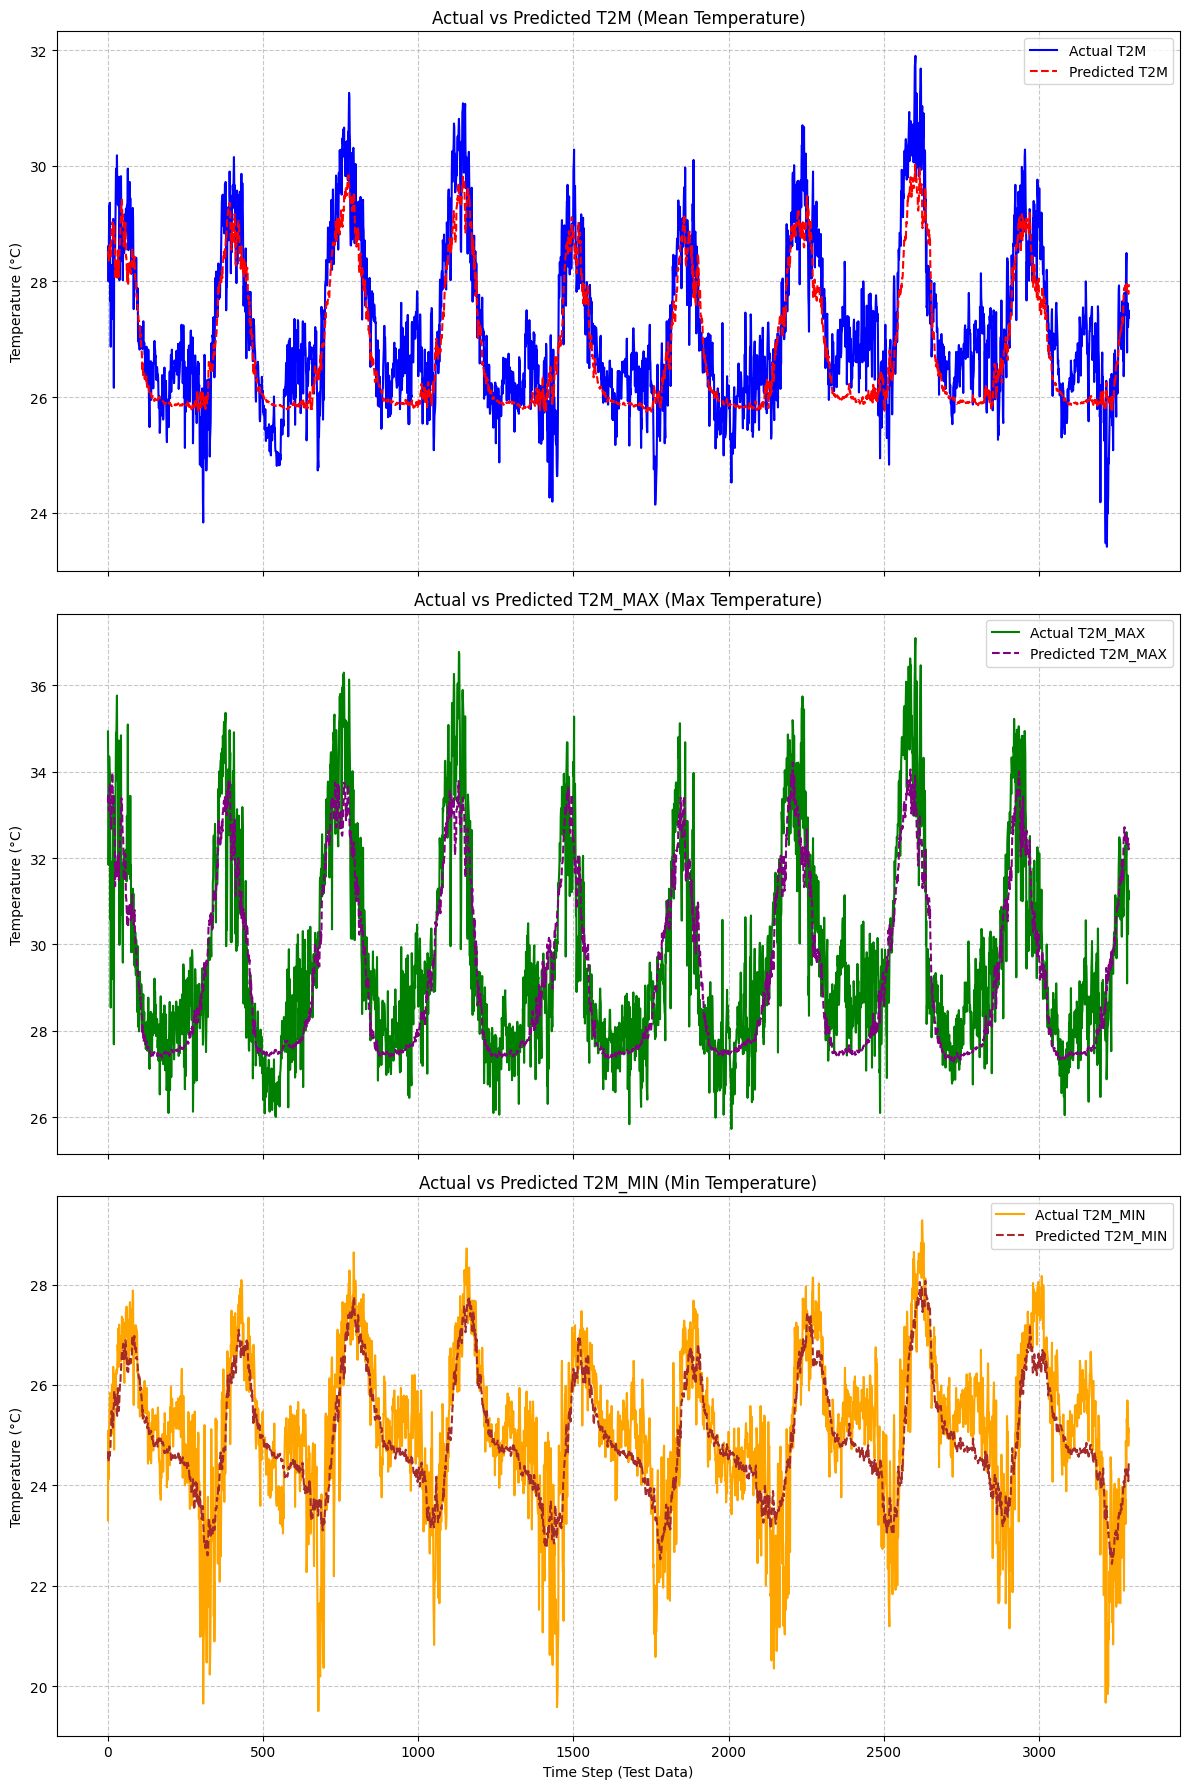

In [ ]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)



# Plot for T2M (Mean Temperature)
axes[0].plot(true[:, 0], label='Actual T2M', color='blue')
axes[0].plot(pred[:, 0], label='Predicted T2M', color='red', linestyle='--')
axes[0].set_title('Actual vs Predicted T2M (Mean Temperature)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot for T2M_MAX (Max Temperature)
axes[1].plot(true[:, 1], label='Actual T2M_MAX', color='green')
axes[1].plot(pred[:, 1], label='Predicted T2M_MAX', color='purple', linestyle='--')
axes[1].set_title('Actual vs Predicted T2M_MAX (Max Temperature)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot for T2M_MIN (Min Temperature)
axes[2].plot(true[:, 2], label='Actual T2M_MIN', color='orange')
axes[2].plot(pred[:, 2], label='Predicted T2M_MIN', color='brown', linestyle='--')
axes[2].set_title('Actual vs Predicted T2M_MIN (Min Temperature)')
axes[2].set_xlabel('Time Step (Test Data)')
axes[2].set_ylabel('Temperature (°C)')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

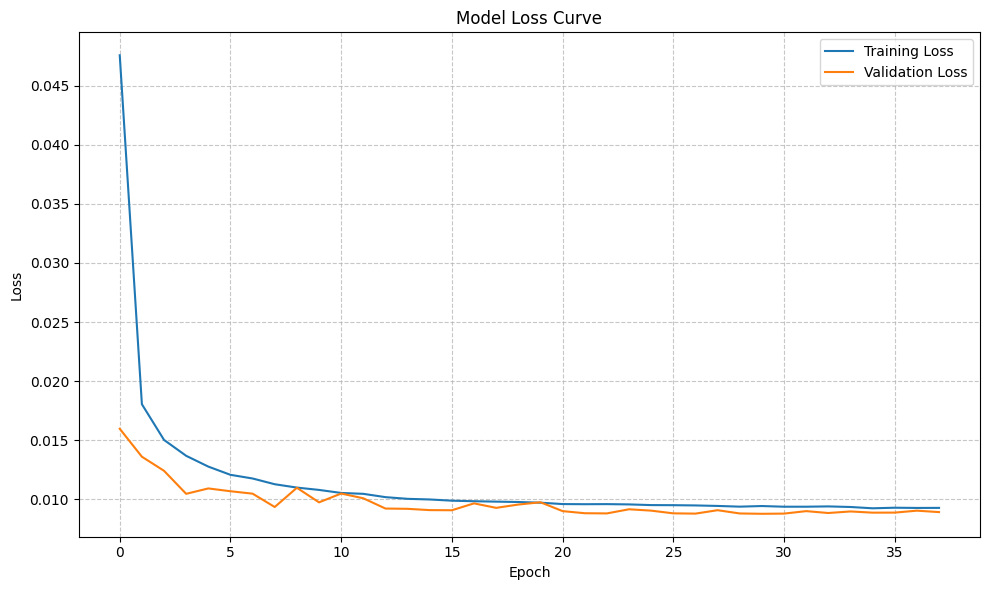

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
def classify_weather(t2m: float, t2m_max: float, t2m_min: float,
                     month: int) -> str:

    tr = t2m_max - t2m_min   # diurnal range

    if month in (12, 1, 2, 3):
        if t2m_max >= 35:                      return "Hot & Sunny"
        if t2m_max >= 32:                      return "Warm & Mostly Sunny"
        if tr >= 7:                            return "Clear & Sunny"
        if 27 <= t2m <= 31:                    return "Partly Cloudy & Pleasant"
        return "Pleasant"

    if month in (4, 5):
        if t2m_max >= 36:                      return "Very Hot, Risk of Thunderstorms"
        if t2m_max >= 33:                      return "Hot & Sunny"
        if tr >= 8:                            return "Hot with Chance of Showers"
        return "Warm & Mostly Sunny"

    if month in (6, 7, 8, 9):
        if tr <= 4:                            return "Heavy Rain / Overcast"
        if tr <= 6:                            return "Rainy & Humid"
        return "Intermittent Showers"

    if month in (10, 11):
        if t2m_min >= 24 and tr <= 6:          return "Rainy / Humid"
        if tr >= 7:                            return "Chance of Showers"
        if t2m_max >= 32:                      return "Warm & Mostly Sunny"
        return "Partly Cloudy"

    return "Partly Cloudy"

In [ ]:
#Overfit Check
pred_train_sc = model.predict(X_train)
pred_train    = scaler_y.inverse_transform(pred_train_sc)
true_train    = scaler_y.inverse_transform(y_train)

r2_train = r2_score(true_train.ravel(), pred_train.ravel())
print(f"  R² (Train) : {r2_train:.4f}")
print(f"  R² (Test)  : {r2:.4f}")


412/412 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
  R² (Train) : 0.8732
  R² (Test)  : 0.8628


In [ ]:
import joblib, os

os.makedirs("model_artifacts", exist_ok=True)

model.save("model_artifacts/model_14day.keras")
joblib.dump(scaler_X, "model_artifacts/scaler_X.pkl")
joblib.dump(scaler_y, "model_artifacts/scaler_y.pkl")
joblib.dump(features,  "model_artifacts/features.pkl")

print("Saved to model_artifacts/:")
for f in sorted(os.listdir("model_artifacts")):
    size = os.path.getsize(f"model_artifacts/{f}") // 1024
    print(f"  {f}  ({size} KB)")


Saved to model_artifacts/:
  features.pkl  (0 KB)
  model_14day.keras  (1072 KB)
  scaler_X.pkl  (2 KB)
  scaler_y.pkl  (1 KB)


In [ ]:
def forecast_n_days_demo(recent_df, model, scaler_X, scaler_y,
                    features_list, horizon=14):
    recent_t2m   = list(recent_df["T2M"].values[-30:])
    current      = recent_df.iloc[-1].to_dict()
    current_date = recent_df.index[-1]
    results      = []

    for _ in range(horizon):
        current_date = current_date + pd.Timedelta(days=1)
        # Use the build_row_demo function defined earlier
        row    = build_row_demo(current, recent_t2m, current_date, features_list)
        scaled = scaler_X.transform(row).reshape(1, 1, len(features_list))
        vals   = scaler_y.inverse_transform(
                     model.predict(scaled, verbose=0))[0]
        t2m, t2m_max, t2m_min = vals[0], vals[1], vals[2]
        cond = classify_weather(t2m, t2m_max, t2m_min, current_date.month)

        results.append({
            "Date"     : current_date.date(),
            "T2M"      : round(t2m,     2),
            "T2M_MAX"  : round(t2m_max, 2),
            "T2M_MIN"  : round(t2m_min, 2),
            "Condition": cond,
        })

        # Update recent_t2m and current for the next iteration's prediction
        recent_t2m.append(t2m)
        if len(recent_t2m) > 30:
            recent_t2m.pop(0)
        current = {
            "T2M": t2m, "T2M_MAX": t2m_max, "T2M_MIN": t2m_min,
            "RH2M"       : current.get("RH2M", 75.0), # Assume RH remains similar
            "PRECTOTCORR": current.get("PRECTOTCORR", 0.0), # Assume no rain for simplicity
            "PS"         : current.get("PS", 100.0),
            "WS2M"       : current.get("WS2M", 3.0),
            "T2MDEW"     : t2m - 3, # Estimate dew point for next day
        }

    return pd.DataFrame(results)

In [ ]:
# Set the desired forecast start date (March 1st, 2026)
forecast_start_date = datetime(2026, 3, 1).date()

# Fetch recent weather data up to the day before the forecast starts
# Use 'seed_date' to get data up to (forecast_start_date - 1 day)
recent_weather_for_forecast_df = fetch_recent_weather_demo(past_days=30, seed_date=forecast_start_date - timedelta(days=1))

# Define the forecast horizon
forecast_horizon = 14

# Generate the multi-day forecast
multi_day_forecast = forecast_n_days_demo(
    recent_weather_for_forecast_df,
    model_loaded,
    scaler_X_loaded,
    scaler_y_loaded,
    features_loaded,
    horizon=forecast_horizon
)

print(f"\n--- {forecast_horizon}-Day Forecast from {forecast_start_date.strftime('%Y-%m-%d')} ---")
display(multi_day_forecast)


--- 14-Day Forecast from 2026-03-01 ---


,Date,T2M,T2M_MAX,T2M_MIN,Condition
0,2026-03-23,26.290001,29.719999,23.389999,Pleasant
1,2026-03-24,26.299999,30.120001,23.040001,Clear & Sunny
2,2026-03-25,26.410000,30.379999,23.030001,Clear & Sunny
3,2026-03-26,26.459999,30.540001,23.010000,Clear & Sunny
4,2026-03-27,26.500000,30.600000,23.030001,Clear & Sunny
5,2026-03-28,26.510000,30.610001,23.030001,Clear & Sunny
6,2026-03-29,26.490000,30.600000,23.020000,Clear & Sunny
7,2026-03-30,26.440001,30.570000,22.950001,Clear & Sunny
8,2026-03-31,26.440001,30.570000,22.930000,Clear & Sunny
9,2026-04-01,26.389999,30.400000,22.980000,Warm & Mostly Sunny


In [ ]:
!pip install -r requirements.txt

In [ ]:
pip install streamlit joblib tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 72.6 MB/s eta 0:00:00


In [ ]:
%%writefile requirements.txt
streamlit>=1.32.0
tensorflow>=2.15.0
numpy>=1.24.0
pandas>=2.0.0
scikit-learn>=1.3.0
requests>=2.31.0
joblib==1.3.2

In [ ]:
"""
Kerala Weather Forecast — Streamlit App
========================================
Matched to: Copy_of_rs.ipynb

Artifacts expected in model_artifacts/:
  model_14day.keras
  scaler_X.pkl
  scaler_y.pkl
  features.pkl

Run locally : streamlit run app.py
Deploy      : Push to GitHub → Streamlit Community Cloud
"""

import streamlit as st
import numpy as np
import pandas as pd
import requests
import joblib
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta, date
from tensorflow.keras.models import load_model

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Kerala Weather Forecast",
    page_icon="🌦",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ── Constants ─────────────────────────────────────────────────────────────────
LAT, LON      = 8.5241, 76.9366
ARTIFACTS_DIR = "model_artifacts"

CONDITION_EMOJI = {
    "Hot & Sunny"                    : "☀️",
    "Warm & Mostly Sunny"            : "🌤",
    "Clear & Sunny"                  : "☀️",
    "Partly Cloudy & Pleasant"       : "🌥",
    "Pleasant"                       : "😊",
    "Very Hot, Risk of Thunderstorms": "🌩",
    "Hot with Chance of Showers"     : "🌦",
    "Heavy Rain / Overcast"          : "🌧",
    "Rainy & Humid"                  : "🌧",
    "Intermittent Showers"           : "🌦",
    "Rainy / Humid"                  : "🌧",
    "Chance of Showers"              : "🌦",
    "Partly Cloudy"                  : "⛅",
}

CONDITION_COLOR = {
    "Hot & Sunny"                    : "#F97316",
    "Warm & Mostly Sunny"            : "#FACC15",
    "Clear & Sunny"                  : "#FDE047",
    "Partly Cloudy & Pleasant"       : "#86EFAC",
    "Pleasant"                       : "#34D399",
    "Very Hot, Risk of Thunderstorms": "#EF4444",
    "Hot with Chance of Showers"     : "#FB923C",
    "Heavy Rain / Overcast"          : "#3B82F6",
    "Rainy & Humid"                  : "#6366F1",
    "Intermittent Showers"           : "#818CF8",
    "Rainy / Humid"                  : "#4F46E5",
    "Chance of Showers"              : "#A78BFA",
    "Partly Cloudy"                  : "#94A3B8",
}

# ── Load artifacts ────────────────────────────────────────────────────────────
@st.cache_resource(show_spinner="Loading model...")
def load_artifacts():
    model    = load_model(f"{ARTIFACTS_DIR}/model_14day.keras")
    scaler_X = joblib.load(f"{ARTIFACTS_DIR}/scaler_X.pkl")
    scaler_y = joblib.load(f"{ARTIFACTS_DIR}/scaler_y.pkl")
    features = joblib.load(f"{ARTIFACTS_DIR}/features.pkl")
    return model, scaler_X, scaler_y, features

# ── Fetch recent weather ──────────────────────────────────────────────────────
@st.cache_data(ttl=3600, show_spinner="Fetching weather data...")
def fetch_recent_weather(seed_date=None, past_days=30):
    end_date = seed_date if seed_date else datetime.now().date()

    if end_date < datetime.now().date():
        url    = "https://archive-api.open-meteo.com/v1/archive"
        start  = (pd.Timestamp(end_date) - pd.Timedelta(days=past_days)).date()
        params = {
            "latitude"  : LAT, "longitude": LON,
            "daily"     : ["temperature_2m_max", "temperature_2m_min",
                           "temperature_2m_mean", "relative_humidity_2m_mean",
                           "windspeed_10m_max", "precipitation_sum",
                           "dewpoint_2m_mean"],
            "start_date": str(start),
            "end_date"  : str(end_date),
            "timezone"  : "Asia/Kolkata",
        }
    else:
        url    = "https://api.open-meteo.com/v1/forecast"
        params = {
            "latitude"      : LAT, "longitude": LON,
            "daily"         : ["temperature_2m_max", "temperature_2m_min",
                               "temperature_2m_mean", "relative_humidity_2m_mean",
                               "windspeed_10m_max", "precipitation_sum",
                               "dewpoint_2m_mean"],
            "past_days"     : past_days,
            "forecast_days" : 1,
            "timezone"      : "Asia/Kolkata",
        }

    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()["daily"]

    df = pd.DataFrame({
        "DATE"       : pd.to_datetime(data["time"]),
        "T2M"        : data["temperature_2m_mean"],
        "T2M_MAX"    : data["temperature_2m_max"],
        "T2M_MIN"    : data["temperature_2m_min"],
        "RH2M"       : data["relative_humidity_2m_mean"],
        "WS2M"       : data["windspeed_10m_max"],
        "PRECTOTCORR": data["precipitation_sum"],
        "T2MDEW"     : data.get("dewpoint_2m_mean", [None]*len(data["time"])),
        "PS"         : [100.0] * len(data["time"]),
    }).set_index("DATE")

    df.replace([None], np.nan, inplace=True)
    df.interpolate(method="time", inplace=True)
    return df

# ── Weather classifier (matches notebook exactly) ────────────────────────────
def classify_weather(t2m, t2m_max, t2m_min, month):
    tr = t2m_max - t2m_min
    if month in (12, 1, 2, 3):
        if t2m_max >= 35:                      return "Hot & Sunny"
        if t2m_max >= 32:                      return "Warm & Mostly Sunny"
        if tr >= 7:                            return "Clear & Sunny"
        if 27 <= t2m <= 31:                    return "Partly Cloudy & Pleasant"
        return "Pleasant"
    if month in (4, 5):
        if t2m_max >= 36:                      return "Very Hot, Risk of Thunderstorms"
        if t2m_max >= 33:                      return "Hot & Sunny"
        if tr >= 8:                            return "Hot with Chance of Showers"
        return "Warm & Mostly Sunny"
    if month in (6, 7, 8, 9):
        if tr <= 4:                            return "Heavy Rain / Overcast"
        if tr <= 6:                            return "Rainy & Humid"
        return "Intermittent Showers"
    if month in (10, 11):
        if t2m_min >= 24 and tr <= 6:          return "Rainy / Humid"
        if tr >= 7:                            return "Chance of Showers"
        if t2m_max >= 32:                      return "Warm & Mostly Sunny"
        return "Partly Cloudy"
    return "Partly Cloudy"

# ── Build feature row ─────────────────────────────────────────────────────────
def build_row(current, recent_t2m, dt, features):
    m, d, w = dt.month, dt.dayofyear, dt.dayofweek
    T     = current.get("T2M",     recent_t2m[-1])
    RH    = current.get("RH2M",    75.0)
    T_max = current.get("T2M_MAX", T + 4)
    T_min = current.get("T2M_MIN", T - 3)
    T_dew = current.get("T2MDEW",  T - 3)
    hi    = max(T, -8.78 + 1.61*T + 2.34*RH - 0.15*T*RH
                - 0.012*T*T - 0.016*RH*RH)

    lag1  = recent_t2m[-1]
    lag2  = recent_t2m[-2]  if len(recent_t2m) >= 2  else lag1
    lag3  = recent_t2m[-3]  if len(recent_t2m) >= 3  else lag1
    lag7  = recent_t2m[-7]  if len(recent_t2m) >= 7  else lag1
    lag14 = recent_t2m[-14] if len(recent_t2m) >= 14 else lag1
    r7    = recent_t2m[-7:]  if len(recent_t2m) >= 7  else recent_t2m
    r14   = recent_t2m[-14:] if len(recent_t2m) >= 14 else recent_t2m
    r30   = recent_t2m[-30:] if len(recent_t2m) >= 30 else recent_t2m

    base = {
        "T2M"             : T,
        "T2M_MAX"         : T_max,
        "T2M_MIN"         : T_min,
        "RH2M"            : RH,
        "PRECTOTCORR"     : current.get("PRECTOTCORR", 0.0),
        "PS"              : current.get("PS", 100.0),
        "WS2M"            : current.get("WS2M", 3.0),
        "T2MDEW"          : T_dew,
        "month_sin"       : np.sin(2 * np.pi * m / 12),
        "month_cos"       : np.cos(2 * np.pi * m / 12),
        "doy_sin"         : np.sin(2 * np.pi * d / 365),
        "doy_cos"         : np.cos(2 * np.pi * d / 365),
        "dow_sin"         : np.sin(2 * np.pi * w / 7),
        "dow_cos"         : np.cos(2 * np.pi * w / 7),
        "T2M_lag1"        : lag1,
        "T2M_lag2"        : lag2,
        "T2M_lag3"        : lag3,
        "T2M_lag7"        : lag7,
        "T2M_lag14"       : lag14,
        "T2M_MAX_lag1"    : T_max,
        "T2M_MAX_lag2"    : T_max,
        "T2M_MAX_lag3"    : T_max,
        "T2M_MAX_lag7"    : T_max,
        "T2M_MAX_lag14"   : T_max,
        "T2M_roll7_mean"  : float(np.mean(r7)),
        "T2M_roll7_std"   : float(np.std(r7)),
        "T2M_roll14_mean" : float(np.mean(r14)),
        "T2M_roll14_std"  : float(np.std(r14)),
        "T2M_roll30_mean" : float(np.mean(r30)),
        "T2M_roll30_std"  : float(np.std(r30)),
        "rain_roll7_sum"  : current.get("PRECTOTCORR", 0.0) * 7,
        "rain_roll14_sum" : current.get("PRECTOTCORR", 0.0) * 14,
        "diurnal_range"   : T_max - T_min,
        "dew_depression"  : T - T_dew,
        "heat_index"      : hi,
    }

    missing = [f for f in features if f not in base]
    if missing:
        raise KeyError(f"Features in features.pkl not in build_row(): {missing}")

    return pd.DataFrame([[base[f] for f in features]], columns=features)

# ── Forecast ──────────────────────────────────────────────────────────────────
def forecast_n_days(recent_df, model, scaler_X, scaler_y, features, horizon=14):
    recent_t2m   = list(recent_df["T2M"].values[-30:])
    current      = recent_df.iloc[-1].to_dict()
    current_date = recent_df.index[-1]
    results      = []

    for _ in range(horizon):
        current_date = current_date + pd.Timedelta(days=1)
        row    = build_row(current, recent_t2m, current_date, features)
        scaled = scaler_X.transform(row).reshape(1, 1, len(features))
        vals   = scaler_y.inverse_transform(
                     model.predict(scaled, verbose=0))[0]
        t2m, t2m_max, t2m_min = vals[0], vals[1], vals[2]
        cond = classify_weather(t2m, t2m_max, t2m_min, current_date.month)

        results.append({
            "Date"     : current_date.date(),
            "T2M"      : round(t2m,     2),
            "T2M_MAX"  : round(t2m_max, 2),
            "T2M_MIN"  : round(t2m_min, 2),
            "Condition": cond,
        })

        recent_t2m.append(t2m)
        if len(recent_t2m) > 30:
            recent_t2m.pop(0)
        current = {
            "T2M": t2m, "T2M_MAX": t2m_max, "T2M_MIN": t2m_min,
            "RH2M"       : current.get("RH2M", 75.0),
            "PRECTOTCORR": current.get("PRECTOTCORR", 0.0),
            "PS"         : current.get("PS", 100.0),
            "WS2M"       : current.get("WS2M", 3.0),
            "T2MDEW"     : t2m - 3,
        }

    return pd.DataFrame(results)

# ── Temperature chart ─────────────────────────────────────────────────────────
def make_temp_chart(recent_df, forecast_df):
    """
    Builds a combined observed + forecast DataFrame for st.line_chart.
    No plotly dependency needed.
    """
    # Observed portion
    obs = pd.DataFrame({
        "Observed max" : recent_df["T2M_MAX"],
        "Observed min" : recent_df["T2M_MIN"],
    }, index=recent_df.index)

    # Forecast portion
    fc_idx = pd.to_datetime(forecast_df["Date"])
    fc = pd.DataFrame({
        "Forecast max"  : forecast_df["T2M_MAX"].values,
        "Forecast mean" : forecast_df["T2M"].values,
        "Forecast min"  : forecast_df["T2M_MIN"].values,
    }, index=fc_idx)

    # Combine — Streamlit will plot all columns on the same axis
    combined = pd.concat([obs, fc], axis=0).sort_index()
    return combined

# ── Weather cards ─────────────────────────────────────────────────────────────
def render_weather_cards(forecast_df):
    cols = st.columns(len(forecast_df))
    for col, (_, row) in zip(cols, forecast_df.iterrows()):
        cond  = row["Condition"]
        emoji = CONDITION_EMOJI.get(cond, "🌡")
        color = CONDITION_COLOR.get(cond, "#94A3B8")
        d     = pd.to_datetime(row["Date"])
        with col:
            st.markdown(
                f"""
                <div style="background:{color}28;border:2px solid {color}88;
                    border-radius:14px;padding:14px 8px;text-align:center;
                    height:200px;display:flex;flex-direction:column;
                    justify-content:space-between;">
                    <div style="font-size:12px;color:#94a3b8;font-weight:600;
                                letter-spacing:0.5px;">
                        {d.strftime("%a").upper()}<br>
                        <span style="font-size:13px;color:#cbd5e1;">
                            {d.strftime("%b %d")}
                        </span>
                    </div>
                    <div style="font-size:32px;line-height:1;">{emoji}</div>
                    <div style="font-size:22px;font-weight:800;color:#f1f5f9;
                                letter-spacing:-0.5px;">
                        {row['T2M']:.1f}°C
                    </div>
                    <div style="font-size:12px;font-weight:600;color:#cbd5e1;">
                        ↑{row['T2M_MAX']:.1f}° &nbsp;·&nbsp; ↓{row['T2M_MIN']:.1f}°
                    </div>
                    <div style="font-size:10px;color:#94a3b8;margin-top:2px;
                                line-height:1.3;">
                        {cond}
                    </div>
                </div>
                """,
                unsafe_allow_html=True,
            )

# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════
def main():

    with st.sidebar:
        st.markdown("## 🌦 Kerala Weather Forecast")
        st.caption("Trivandrum · LSTM Deep Learning")
        st.markdown("---")

        horizon = st.radio(
            "Forecast horizon",
            options=[7, 14],
            format_func=lambda x: f"{x} days",
            horizontal=True,
        )

        st.markdown("---")
        st.markdown("**Forecast start date**")
        st.caption(
            "Model uses real observed weather up to this date as seed. "
            "Default is March 1 — first day after training cutoff."
        )
        forecast_start = st.date_input(
            "Start from",
            value=date(2026, 3, 1),
            min_value=date(2026, 3, 1),
            max_value=datetime.now().date(),
            label_visibility="collapsed",
        )

        st.markdown("---")
        st.markdown("**Data**")
        st.markdown(
            "🗓 Training cutoff: **28 Feb 2026**  \n"
            "📡 Live seed: [Open-Meteo](https://open-meteo.com/) (free)  \n"
            f"📍 Trivandrum `{LAT}°N, {LON}°E`"
        )

        st.markdown("---")
        show_metrics = st.toggle("Show model metrics", value=False)
        show_table   = st.toggle("Show forecast table", value=False)

    # ── Load ──────────────────────────────────────────────────────────────────
    try:
        model, scaler_X, scaler_y, features = load_artifacts()
    except Exception as e:
        st.error(
            f"Could not load artifacts from `{ARTIFACTS_DIR}/`.  \n"
            f"Run notebook and save artifacts first.  \n`{e}`"
        )
        st.stop()

    # ── Fetch seed data ───────────────────────────────────────────────────────
    try:
        seed_date = forecast_start - timedelta(days=1)
        recent_df = fetch_recent_weather(seed_date=seed_date, past_days=30)
    except Exception as e:
        st.error(f"Could not fetch weather data: `{e}`")
        st.stop()

    # ── Generate forecast ─────────────────────────────────────────────────────
    with st.spinner(f"Generating {horizon}-day forecast..."):
        forecast_df = forecast_n_days(
            recent_df, model, scaler_X, scaler_y, features, horizon=horizon
        )

    # ── Header ────────────────────────────────────────────────────────────────
    st.markdown("# 🌦 Kerala Weather Forecast")
    is_live = forecast_start >= datetime.now().date()
    mode    = "Live forecast" if is_live else \
              f"Forecast from {forecast_start.strftime('%d %b %Y')}"
    st.caption(
        f"Trivandrum (Thiruvananthapuram) · {mode} · "
        f"Training cutoff: 28 Feb 2026"
    )

    # ── Day-1 card ────────────────────────────────────────────────────────────
    st.markdown("---")
    row1      = forecast_df.iloc[0]
    day1_temp = row1["T2M"]
    day1_cond = row1["Condition"]
    day1_date = pd.Timestamp(row1["Date"])
    emoji     = CONDITION_EMOJI.get(day1_cond, "🌡")
    color     = CONDITION_COLOR.get(day1_cond, "#94A3B8")
    last      = recent_df.iloc[-1]

    day1_label = (
        f"Tomorrow — {day1_date.strftime('%A, %d %b %Y')}"
        if is_live else
        f"Day 1 forecast — {day1_date.strftime('%A, %d %b %Y')}"
    )
    obs_label = "Today" if is_live else \
                f"Last observed ({recent_df.index[-1].strftime('%d %b')})"

    c1, c2, c3, c4, c5 = st.columns([2.5, 1, 1, 1, 1])
    with c1:
        st.markdown(
            f"""
            <div style="background:{color}18;border:2px solid {color}55;
                        border-radius:16px;padding:20px 24px;">
                <div style="font-size:12px;color:#64748b;margin-bottom:6px;">
                    {day1_label}
                </div>
                <div style="display:flex;align-items:center;gap:16px;">
                    <span style="font-size:48px;">{emoji}</span>
                    <div>
                        <div style="font-size:38px;font-weight:700;
                                    color:#1e293b;line-height:1.1;">
                            {day1_temp:.1f}°C
                        </div>
                        <div style="font-size:14px;color:#475569;">
                            {day1_cond}
                        </div>
                    </div>
                </div>
            </div>
            """,
            unsafe_allow_html=True,
        )
    with c2:
        st.metric(f"{obs_label} max", f"{last['T2M_MAX']:.1f}°C")
    with c3:
        st.metric(f"{obs_label} min", f"{last['T2M_MIN']:.1f}°C")
    with c4:
        st.metric("Humidity", f"{last['RH2M']:.0f}%")
    with c5:
        st.metric("Wind",     f"{last['WS2M']:.1f} m/s")

    # ── Forecast cards ────────────────────────────────────────────────────────
    st.markdown("---")
    fc_start_str = pd.Timestamp(forecast_df.iloc[0]["Date"]).strftime("%d %b")
    fc_end_str   = pd.Timestamp(forecast_df.iloc[-1]["Date"]).strftime("%d %b %Y")
    st.markdown(
        f"### {horizon}-Day Forecast &nbsp;"
        f"<span style='font-size:14px;color:#64748b;font-weight:400;'>"
        f"{fc_start_str} → {fc_end_str}</span>",
        unsafe_allow_html=True,
    )
    render_weather_cards(forecast_df)

    # ── Chart ─────────────────────────────────────────────────────────────────
    st.markdown("---")
    st.markdown("### Temperature trend")
    chart_data = make_temp_chart(recent_df, forecast_df)
    st.line_chart(chart_data, height=420, use_container_width=True)

    # ── Metrics ───────────────────────────────────────────────────────────────
    if show_metrics:
        st.markdown("---")
        st.markdown("### Model performance")
        st.caption(
            "14-day ahead forecast · Targets: T2M, T2M_MAX, T2M_MIN · "
            "80/20 chronological split"
        )
        m1, m2, m3, m4 = st.columns(4)
        m1.metric("R²",   "0.8628",   help="Proportion of variance explained")
        m2.metric("MAE",  "0.7431°C", help="Mean Absolute Error across all 3 targets")
        m3.metric("RMSE", "0.9597°C", help="Root Mean Squared Error")
        m4.metric("MAPE", "2.704%",   help="Mean Absolute Percentage Error")
        st.caption(
            "Trained on NASA/POWER MERRA-2 · Jan 1981 – Feb 2026 · "
            "45 years · 16,495 rows"
        )

    # ── Raw table ─────────────────────────────────────────────────────────────
    if show_table:
        st.markdown("---")
        st.markdown("### Raw forecast data")
        st.dataframe(
            forecast_df.style.format({
                "T2M"    : "{:.2f}°C",
                "T2M_MAX": "{:.2f}°C",
                "T2M_MIN": "{:.2f}°C",
            }),
            use_container_width=True,
            hide_index=True,
        )

    # ── Download ──────────────────────────────────────────────────────────────
    st.markdown("---")
    st.download_button(
        label="⬇️ Download forecast as CSV",
        data=forecast_df.to_csv(index=False),
        file_name=f"trivandrum_forecast_{forecast_start.strftime('%Y%m%d')}.csv",
        mime="text/csv",
    )

    st.caption(
        "Built with LSTM · Training: NASA/POWER MERRA-2 (1981–2026) · "
        "Live seed: Open-Meteo API · "
        f"Last updated {datetime.now().strftime('%d %b %Y')}"
    )


if __name__ == "__main__":
    main()